In [3]:
import kagglehub
import pandas as pd
import os

# 1. Download dataset secara utuh
# Ini akan mengambil versi terbaru yang tersedia secara otomatis
path = kagglehub.dataset_download("ihelon/coffee-sales")

print(f"Dataset terunduh di: {path}")

# 2. Cek daftar file yang ada di folder tersebut (biar tidak salah nama)
files = os.listdir(path)
print(f"Daftar file: {files}")

# 3. Load file index.csv menggunakan pandas biasa
# Kita gabungkan path folder dengan nama filenya
if "index.csv" in files:
    df = pd.read_csv(os.path.join(path, "index.csv"))
    print("\n--- Berhasil Load Data ---")
    print(df.head())
else:
    print("\nFile index.csv tidak ditemukan, coba cek daftar file di atas.")

/home/rima/Documents/DS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset terunduh di: /home/rima/.cache/kagglehub/datasets/ihelon/coffee-sales/versions/21
Daftar file: ['index_2.csv', 'index_1.csv']

File index.csv tidak ditemukan, coba cek daftar file di atas.


In [4]:
import pandas as pd
import os
import kagglehub

# 1. Download dataset-nya
path = kagglehub.dataset_download("ihelon/coffee-sales")

# 2. Definisikan path lengkap untuk kedua file
path_1 = os.path.join(path, "index_1.csv")
path_2 = os.path.join(path, "index_2.csv")

# 3. Baca masing-masing file
df1 = pd.read_csv(path_1)
df2 = pd.read_csv(path_2)

# 4. Gabungkan keduanya (Concatenate)
# ignore_index=True supaya urutan barisnya rapi dari 0 sampai akhir
df = pd.concat([df1, df2], ignore_index=True)

print(f"Data 1: {len(df1)} baris")
print(f"Data 2: {len(df2)} baris")
print(f"Total setelah digabung: {len(df)} baris")

# Tampilkan 5 baris pertama
print(df.head())

Data 1: 3636 baris
Data 2: 262 baris
Total setelah digabung: 3898 baris
         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  


In [5]:
import pandas as pd
import numpy as np

# --- 1. Pengecekan Missing Value (Sesuai Modul 4) ---
print("--- Check Missing Value ---")
print(df.isnull().sum())

# --- 2. Penanganan Missing Value (Sesuai Teknik di Modul) ---

# A. Menghapus baris yang kolom kategorikalnya kosong (coffee_name, cash_type)
# Karena jika jenis kopi tidak ada, data tidak bisa dianalisis dengan baik
df_clean = df.dropna(subset=['coffee_name', 'cash_type']).copy()

# B. Mengisi Missing Value pada kolom numerik (money) dengan nilai MEAN
# Modul 4 menyarankan pengisian nilai numerik yang kosong dengan rata-rata
mean_money = df_clean['money'].mean()
df_clean['money'] = df_clean['money'].fillna(mean_money)

# C. Tambahan: Untuk kolom 'card', karena kosong berarti bayar 'Cash', 
df_clean['card'] = df_clean['card'].fillna('N/A')

print("\n--- Check Missing Value Setelah Penanganan ---")
print(df_clean.isnull().sum())

# --- 3. Penanganan Outlier (Metode IQR Sesuai Modul 4) ---
Q1 = df_clean['money'].quantile(0.25)
Q3 = df_clean['money'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

# Menyaring data yang berada di dalam rentang limit (bukan outlier)
df_final = df_clean[(df_clean['money'] >= lower_limit) & (df_clean['money'] <= upper_limit)]

print(f"\nJumlah data awal: {len(df)}")
print(f"Jumlah data setelah penanganan missing value & outlier: {len(df_final)}")

--- Check Missing Value ---
date             0
datetime         0
cash_type        0
card           351
money            0
coffee_name      0
dtype: int64

--- Check Missing Value Setelah Penanganan ---
date           0
datetime       0
cash_type      0
card           0
money          0
coffee_name    0
dtype: int64

Jumlah data awal: 3898
Jumlah data setelah penanganan missing value & outlier: 3882


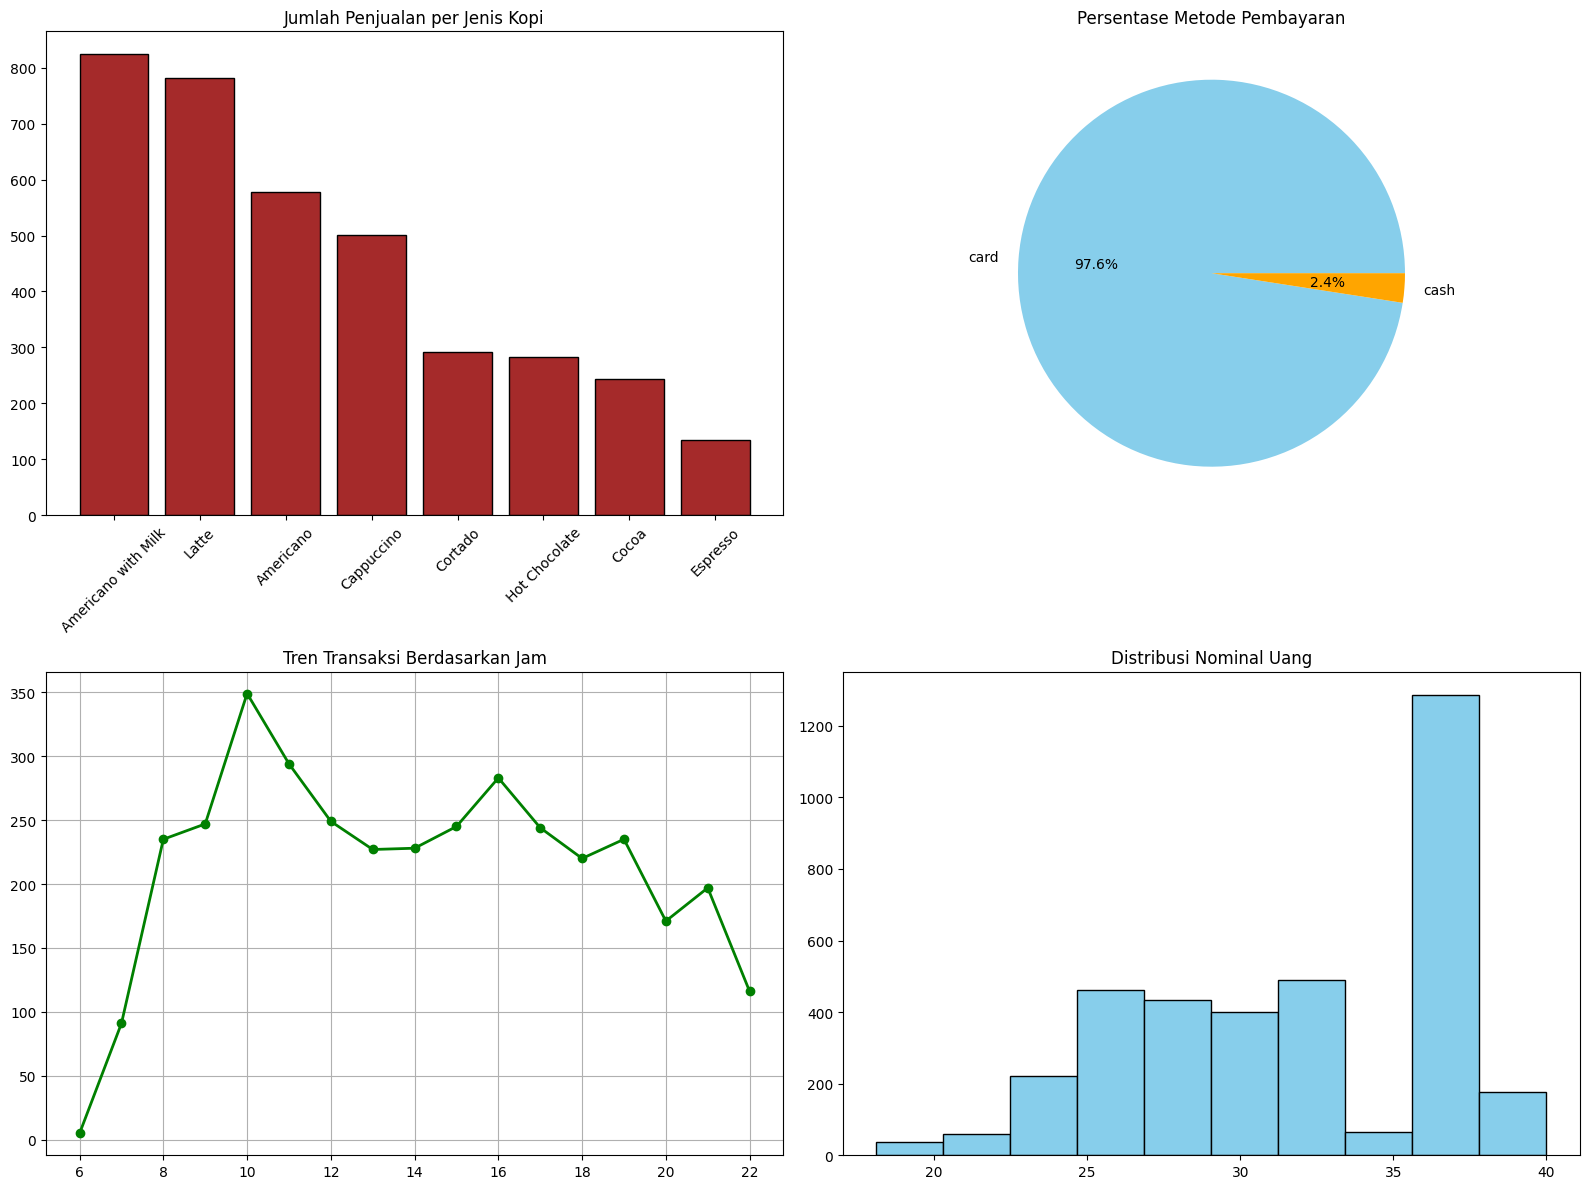


--- RINGKASAN DATA ---
Total Baris Data: 3636
Produk Terlaris: Americano with Milk
Jam Paling Sibuk: Jam 10


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

# --- 1. JOINING DATA (Modul 5) ---
path = kagglehub.dataset_download("ihelon/coffee-sales")
df1 = pd.read_csv(os.path.join(path, "index_1.csv"))
df2 = pd.read_csv(os.path.join(path, "index_2.csv"))
data = pd.concat([df1, df2], ignore_index=True)

# --- 2. PRAPROSES MISSING DATA (Modul 4) ---
# Hapus baris kosong di kategori
data = data.dropna(subset=['coffee_name', 'cash_type'])
# Isi numerik kosong dengan mean
data['money'] = data['money'].fillna(data['money'].mean())

# FIX: Convert datetime dengan penanganan error (Modul 4 & 5 logic)
data['datetime'] = pd.to_datetime(data['datetime'], errors='coerce')
# Hapus jika ada tanggal yang gagal di-convert
data = data.dropna(subset=['datetime'])

# --- 3. PRAPROSES OUTLIER DATA (Modul 4 Hal 10) ---
# Sesuai modul: Gunakan replace untuk memperbaiki data yang ekstrem (> 500)
data['money'] = data['money'].apply(lambda x: 35 if x > 500 else x)

# --- 4. VISUALISASI INFORMASI MAKSIMAL (Modul 6) ---
plt.figure(figsize=(16, 12))

# A. Bar Chart: Penjualan per Kopi
plt.subplot(2, 2, 1)
data_produk = data['coffee_name'].value_counts()
plt.bar(data_produk.index, data_produk.values, color='brown', edgecolor='black')
plt.title("Jumlah Penjualan per Jenis Kopi")
plt.xticks(rotation=45)

# B. Pie Chart: Metode Pembayaran
plt.subplot(2, 2, 2)
data_pie = data['cash_type'].value_counts()
plt.pie(data_pie, labels=data_pie.index, autopct='%1.1f%%', colors=['skyblue', 'orange'])
plt.title("Persentase Metode Pembayaran")

# C. Line Plot: Tren Jam Sibuk
plt.subplot(2, 2, 3)
data['hour'] = data['datetime'].dt.hour
data_waktu = data.groupby('hour')['money'].count()
plt.plot(data_waktu.index, data_waktu.values, marker='o', color='green', linewidth=2)
plt.title("Tren Transaksi Berdasarkan Jam")
plt.grid(True)

# D. Histogram: Distribusi Harga
plt.subplot(2, 2, 4)
plt.hist(data['money'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribusi Nominal Uang")

plt.tight_layout()
plt.show()

# --- 5. RINGKASAN DATA ---
print("\n--- RINGKASAN DATA ---")
print(f"Total Baris Data: {len(data)}")
print(f"Produk Terlaris: {data['coffee_name'].mode()[0]}")
print(f"Jam Paling Sibuk: Jam {int(data['hour'].mode()[0])}")

In [7]:
df.describe()

,money
count,3898.00000
mean,31.38060
std,5.06461
min,15.00000
25%,27.92000
50%,32.82000
75%,35.76000
max,40.00000
